## **Summary**
This dataset contains records of profanity and death events across 7 Quentin Tarantino films. The dataset covers 60 unique profane words and death events across films spanning multiple genres like Crime, Action, War, and Western. This analysis aims to explore the level of profanity in Tarantino films.

#### **Features**
    Movie: Title of the Tarantino film in which the event occurred (7 unique films)
    Type: Category of the event — either 'word' (a profane word was spoken) or 'death' (a character died)
    Word: The specific profane word spoken. Only populated when type == 'word'; None for death events
    Minutes_in: Timestamp (in minutes) within the film when the event occurred

In [38]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## **Import Libraries**


In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [40]:
'''
Run on Kaggle or Google Colab
#df = pd.read_csv('kaggle/input/datasets/ibrahimqasimi/tarantino-films-f-words-and-deaths/19_Tarantino_Profanity_Deaths.csv')
'''

#Run it locally with you Kaggle API token
import kagglehub
kagglehub.login()

from pathlib import Path
path = kagglehub.dataset_download("ibrahimqasimi/tarantino-films-f-words-and-deaths")
csv_path = Path(path) / "19_Tarantino_Profanity_Deaths.csv"

df = pd.read_csv(csv_path)

## **EDA**

### **Data Exploration**
    During this step we can explore the shape of the data we are working with. It's usual to check and deal with the number of columns and rows, missing values, outliers and other inconsistencies that might appear.
--


In [41]:
df.shape

(1894, 4)

In [42]:
data_dictionary = {
    "movie": "Title of the Tarantino film in which the event occurred (7 unique films).",
    "type": "Category of the event — either 'word' (a profane word was spoken) or 'death' (a character died).",
    "word": "The specific profane word spoken. Only populated when type == 'word'; None for death events.",
    "minutes_in": "Timestamp (in minutes) within the film when the event occurred.",
}

pd.DataFrame(
    {"Column": data_dictionary.keys(), "Description": data_dictionary.values()}
)

,Column,Description
0,movie,Title of the Tarantino film in which the event...
1,type,Category of the event — either 'word' (a profa...
2,word,The specific profane word spoken. Only populat...
3,minutes_in,Timestamp (in minutes) within the film when th...


In [43]:
data_check = pd.DataFrame({
    "Column": df.columns,
    "Data Type": [df[col].dtype for col in df.columns],
    "Missing Values": [f"{df[col].isna().mean() * 100:.1f}%" for col in df.columns],
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Example Value": [df[col].dropna().iloc[0] if df[col].notna().any() else None for col in df.columns]
})
data_check

,Column,Data Type,Missing Values,Unique Values,Example Value
0,movie,str,0.0%,7,Reservoir Dogs
1,type,str,0.0%,2,word
2,word,str,10.0%,60,dick
3,minutes_in,float64,0.0%,1690,0.4


In [44]:
death_mask  = df['type'] == "death"
df[death_mask]

,movie,type,word,minutes_in
268,Reservoir Dogs,death,NaN,59.93
385,Reservoir Dogs,death,NaN,85.58
386,Reservoir Dogs,death,NaN,85.58
387,Reservoir Dogs,death,NaN,85.81
389,Reservoir Dogs,death,NaN,86.55
...,...,...,...,...
1521,Django Unchained,death,NaN,160.45
1625,Jackie Brown,death,NaN,23.08
1807,Jackie Brown,death,NaN,113.28
1840,Jackie Brown,death,NaN,125.43


In [45]:
df['word'] = df['word'].fillna("None")

In [46]:
movie_list = list(df['movie'].unique())
movie_list

['Reservoir Dogs',
 'Pulp Fiction',
 'Kill Bill: Vol. 1',
 'Kill Bill: Vol. 2',
 'Inglorious Basterds',
 'Django Unchained',
 'Jackie Brown']

In [47]:
movie_genre = {
    'Reservoir Dogs': 'Crime',
    'Pulp Fiction': 'Crime',
    'Kill Bill: Vol. 1': 'Action',
    'Kill Bill: Vol. 2': 'Action',
    'Inglorious Basterds': 'War',
    'Django Unchained': 'Western',
    'Jackie Brown': 'Crime'
}
def assign_genre(movie: str):
    return movie_genre.get(movie, "Unknown")

df["genre"] = df["movie"].map(assign_genre)

## **Statistical Analysis**
    This step seeks to understand the interaction and correlation among the features. Here it's possible to check multicolinearity, plot visulizations and highlight key points.
--

#### Movie Overivew

In [48]:
movies_overview = df.groupby(['movie','genre']).agg(
    f_word_count=('type',lambda x: (x == 'word').sum()),
    duration_min=('minutes_in', 'max'),
    death_count=('type', lambda x: (x == 'death').sum())).reset_index()

movies_overview['wpm'] = (movies_overview['f_word_count'] / movies_overview['duration_min']).round(2)
movies_overview['dpm'] = (movies_overview['death_count'] / movies_overview['duration_min']).round(2)
movies_overview

,movie,genre,f_word_count,duration_min,death_count,wpm,dpm
0,Django Unchained,Western,262,160.45,47,1.63,0.29
1,Inglorious Basterds,War,58,148.73,48,0.39,0.32
2,Jackie Brown,Crime,368,143.13,4,2.57,0.03
3,Kill Bill: Vol. 1,Action,57,100.10,63,0.57,0.63
4,Kill Bill: Vol. 2,Action,69,121.12,11,0.57,0.09
5,Pulp Fiction,Crime,469,148.15,7,3.17,0.05
6,Reservoir Dogs,Crime,421,95.40,10,4.41,0.10


##### Death vs F-word per Movie


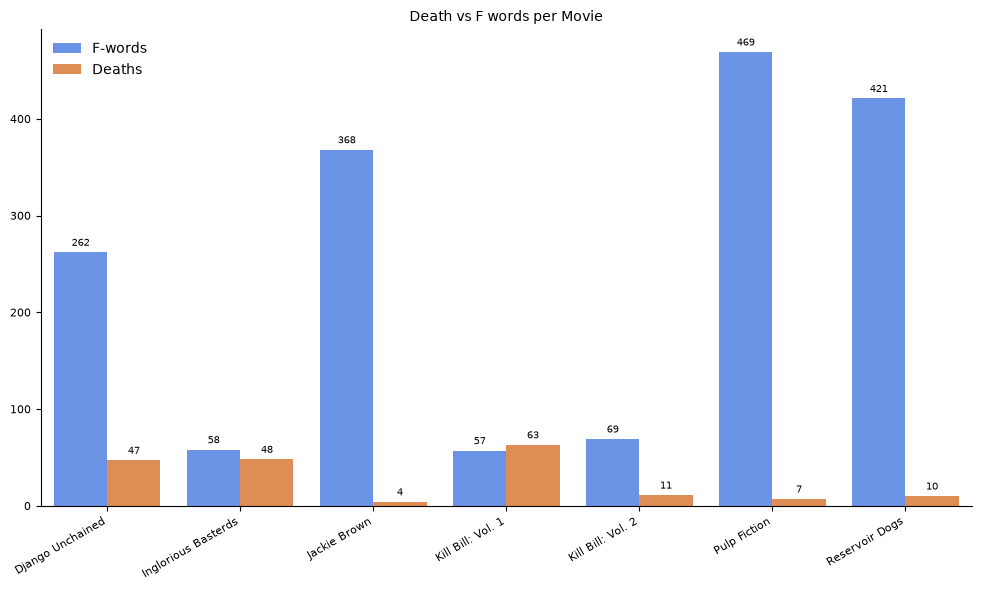

In [49]:
plot_df = movies_overview[['movie', 'f_word_count', 'death_count']].rename(
    columns={'f_word_count': 'F-words', 'death_count': 'Deaths'}).melt(id_vars='movie', var_name='type', value_name='count')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_df, x='movie', y='count', hue='type', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fontsize=7, padding=3)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.set_title('Death vs F words per Movie', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('')
ax.legend(loc='upper left', frameon=False)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

##### Deaths per minute vs F-word per minute

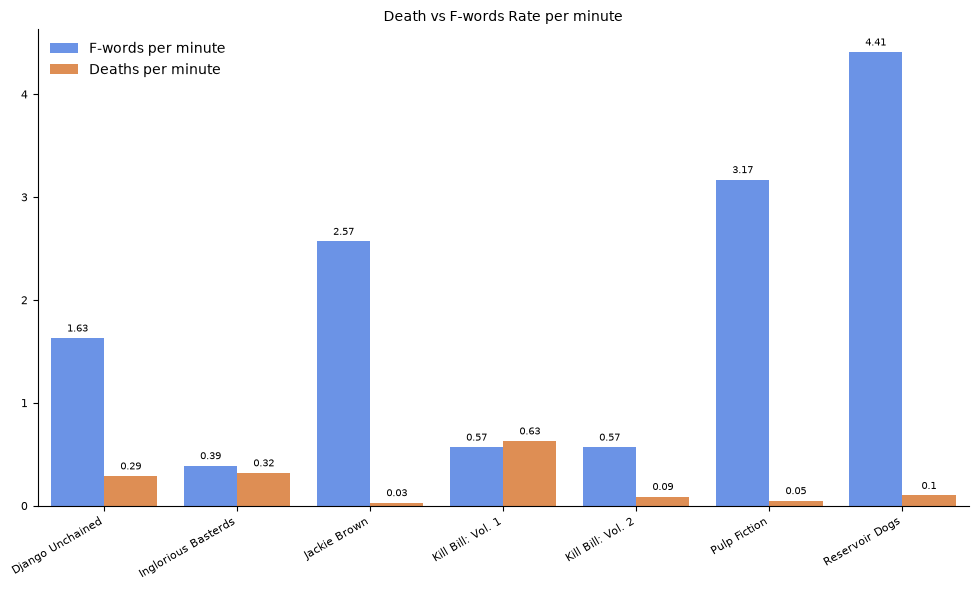

In [50]:
plot_df_metrics = movies_overview[['movie', 'wpm', 'dpm']].rename(
    columns={'wpm': 'F-words per minute', 'dpm': 'Deaths per minute'}).melt(id_vars='movie', var_name='type', value_name='value')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_df_metrics, x='movie', y='value', hue='type', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fontsize=7, padding=3)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.set_title('Death vs F-words Rate per minute', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('')
ax.legend(loc='upper left', frameon=False)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

#### Genre Overivew

In [52]:
genre_overview = movies_overview.groupby(['genre']).agg(
    f_word_count=('f_word_count','sum'),
    duration_min=('duration_min', 'sum'),
    death_count=('death_count','sum')).reset_index()

genre_overview['wpm'] = (genre_overview['f_word_count'] / genre_overview['duration_min']).round(2)
genre_overview['dpm'] = (genre_overview['death_count'] / genre_overview['duration_min']).round(2)
genre_overview

,genre,f_word_count,duration_min,death_count,wpm,dpm
0,Action,126,221.22,74,0.57,0.33
1,Crime,1258,386.68,21,3.25,0.05
2,War,58,148.73,48,0.39,0.32
3,Western,262,160.45,47,1.63,0.29


##### Death vs F-word per Genre

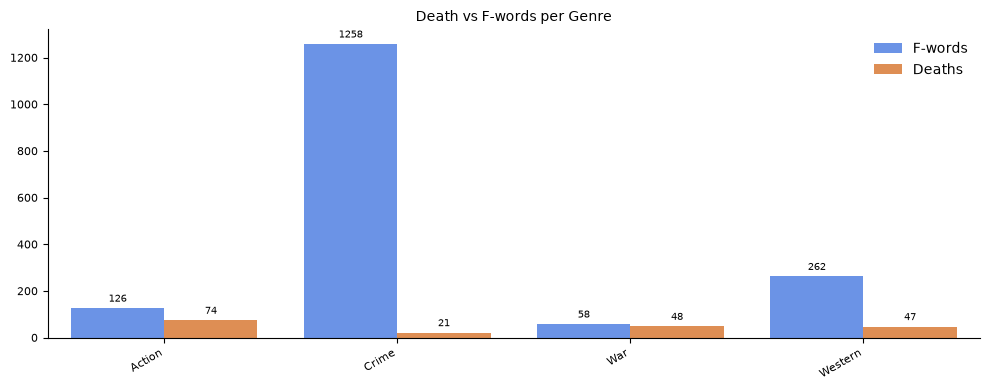

In [53]:
plot_df_v2 = genre_overview[['genre', 'f_word_count', 'death_count']].rename(
    columns={'f_word_count': 'F-words', 'death_count': 'Deaths'}).melt(id_vars='genre', var_name='type', value_name='count')

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=plot_df_v2, x='genre', y='count', hue='type', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fontsize=7, padding=3)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.set_title('Death vs F-words per Genre', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('')
ax.legend(loc='upper right', frameon=False)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

##### Deaths per minute vs F-word per minute

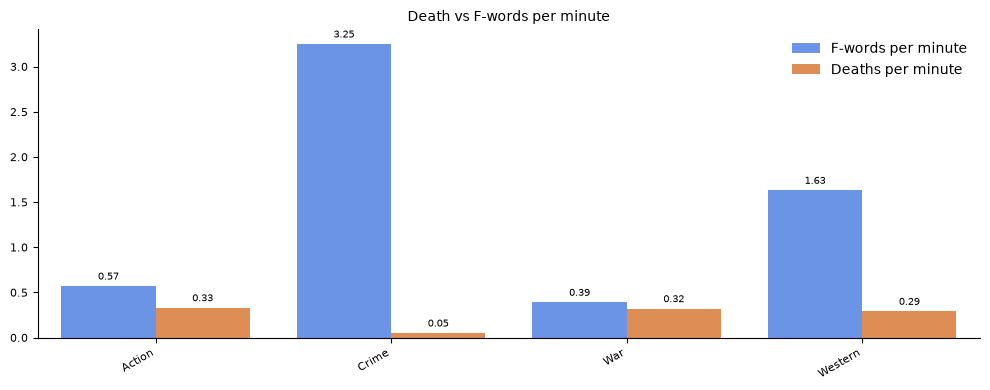

In [54]:
plot_df_v2 = genre_overview[['genre', 'wpm', 'dpm']].rename(
    columns={'wpm': 'F-words per minute', 'dpm': 'Deaths per minute'}).melt(id_vars='genre', var_name='type', value_name='value')

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=plot_df_v2, x='genre', y='value', hue='type', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fontsize=7, padding=3)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.set_title('Death vs F-words per minute', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('')
ax.legend(loc='upper right', frameon=False)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

In [56]:
encoded_genre = pd.get_dummies(genre_overview, columns=['genre'], dtype='int')
encoded_genre['p_metric'] = encoded_genre['wpm'] + encoded_genre['dpm']
encoded_genre

,f_word_count,duration_min,death_count,wpm,dpm,genre_Action,genre_Crime,genre_War,genre_Western,p_metric
0,126,221.22,74,0.57,0.33,1,0,0,0,0.90
1,1258,386.68,21,3.25,0.05,0,1,0,0,3.30
2,58,148.73,48,0.39,0.32,0,0,1,0,0.71
3,262,160.45,47,1.63,0.29,0,0,0,1,1.92


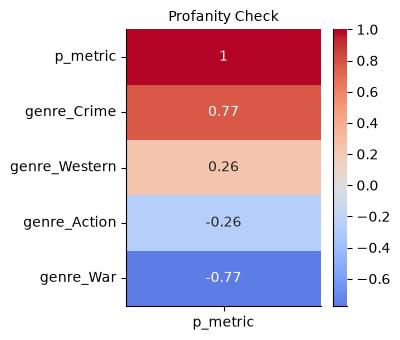

In [57]:
features = ['genre_Action', 'genre_Crime','genre_War', 'genre_Western','p_metric']
corr_ = encoded_genre[features].corr(method="spearman")
target_corr = corr_[['p_metric']].sort_values(by='p_metric', ascending=False)

plt.figure(figsize=(4, len(target_corr) * 0.7))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', center=0)
sns.despine(left=False, right=True, top=True, bottom=False)
plt.title("Profanity Check", fontsize=10)
plt.tight_layout()

## **Insights:**
--

### **Statistics**:
* Pulp fiction, Reservoir Dogs and Jackie Brown are the movies with most F-words per minute. They are also among the movies with the lowest number of deaths.
* While Pulp Fiction is the movie with most F-words, Reservoir Dogs shows a rate of almost 5 F-words per minute, followed by Pulp Fiction with almost 3 and Jackie Brown with around 2.
* Crime is by far the most profane genre among Tarantino movies with +1,200 F-words and a rate of around 3 words per minute, followed by Western, with +200 words and a rate of almost 2.
* Correlations: When checking the genres against the P Metric (Words per minute + Deaths per minute), it's evident that Crime is the genre with the biggest positive correlation while War is the least.

# **Thank You for taking the time to view this Notebook**!
​
If you found this analysis useful and have any feedback or suggestions, don't hesitate to contact me! We are here to learn!